In [1]:
from loaders import load_tisch, load_sept, load_bible, load_references
import numpy as np
import pandas as pd

In [2]:
bible = load_bible()
bible.index = np.arange(len(bible))
references = load_references()

In [3]:
bible_books = bible["book"].unique()
book_map = pd.Series(np.arange(1, len(bible_books) + 1), index=bible_books)
bible["booknum"] = book_map[bible["book"]].values

In [4]:
references["obook"] = bible.iloc[references["ostart"]]["book"].values
references["nbook"] = bible.iloc[references["nstart"]]["book"].values

In [5]:
ot = bible.query("booknum < 40")
nt = bible.query("booknum >= 40")

In [6]:

ot_books = pd.Series(ot["book"].unique())
ot_books.index = ot_books
nt_books = pd.Series(nt["book"].unique())
nt_books.index = nt_books

In [7]:
nt['reference_text'] = False
for obook in ot_books:
    nt[f"reference_{obook}"] = False

for ostart, nstart, nend in references[["ostart", "nstart", "nend"]].values:
    nt.loc[nstart : nend - 1, "reference_text"] = True
    obook = ot.iloc[ostart]['book']
    nt.loc[nstart : nend - 1, f"reference_{obook}"] = True

/tmp/ipykernel_554012/3806089295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nt['reference_text'] = False
/tmp/ipykernel_554012/3806089295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nt[f"reference_{obook}"] = False
/tmp/ipykernel_554012/3806089295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

In [8]:
use_counts = (
    nt.groupby("book")
    .apply(
        lambda book: ot_books.apply(lambda obook: book[f'reference_{obook}'].sum()),
        include_groups=False,
    )
    .reindex(nt_books, columns=ot_books)
    .fillna(0)
    .astype(int)
)
total_quoted = nt.groupby("book")["reference_text"].sum().loc[use_counts.index]
book_lens = nt["book"].value_counts().loc[use_counts.index]

In [10]:
import seaborn as sns
sns.set_theme(style='white')

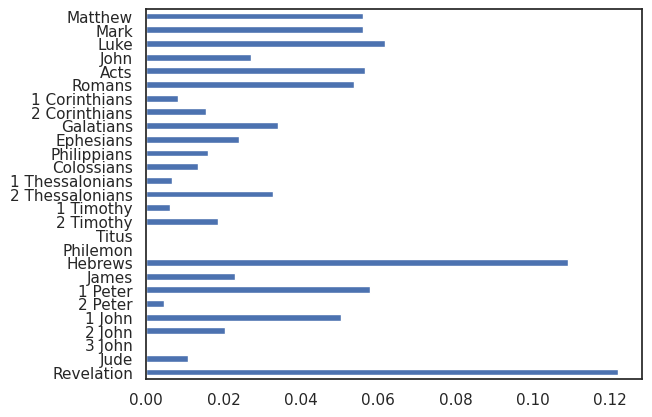

In [11]:
use_props = use_counts / book_lens.values[:, None]
total_props = total_quoted / book_lens.values
total_props[::-1].plot.barh(ylabel='');

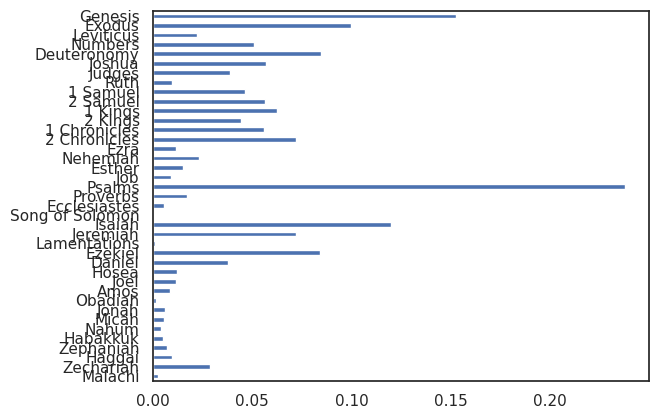

In [12]:
use_props.T.sum(axis=1)[::-1].plot.barh(ylabel='');

In [13]:
from sklearn.decomposition import PCA

In [14]:
import plotly.express as px

In [15]:
flat_props = use_props.values.flatten()
minv = flat_props[flat_props != 0].min()
pca = PCA(n_components=2)
logged_props = np.log(use_props+minv)

In [102]:
def plot(logged_props, books, scale, **kwargs):
    pca = PCA(n_components=2)
    new_comps = pca.fit_transform(logged_props)
    print(pca.explained_variance_ratio_.sum())

    new_df = pd.DataFrame(data=new_comps, columns=['x', 'y'])
    new_df['book'] = books
    new_df = new_df[['book', 'x', 'y']]

    ax = sns.scatterplot(
        new_df,
        x = 'y',
        y = 'x',
        **kwargs
    )
    for x, y, book in new_df[['x', 'y', 'book']].values:
        ax.annotate(book, (y, x))
    ax.set_axis_off()
    ax.figure.set_size_inches(scale * (new_df['y'].max() - new_df['y'].min()), scale * (new_df['x'].max() - new_df['x'].min()))
    return ax

In [118]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
labels = hc.fit_predict(logged_props)

In [84]:
import matplotlib.pyplot as plt

0.6701637520037315


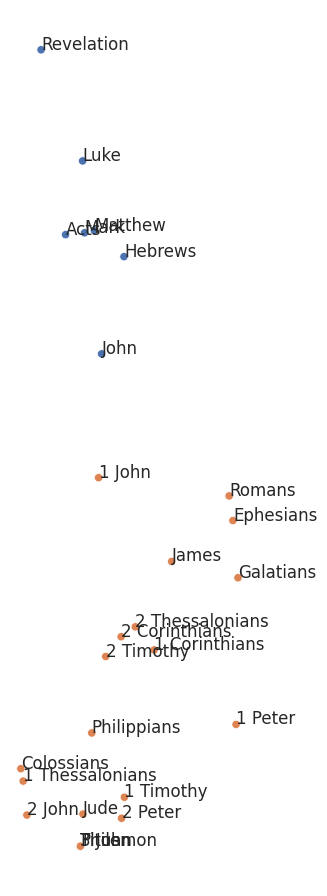

In [119]:
ax = plot(logged_props, nt_books.values, hue=labels.astype(str), scale=.5)
ax.get_legend().remove()
plt.tight_layout()
ax.figure.savefig('../Desktop/nt.png')

In [117]:
for label in range(3):
    print(*nt_books[labels == label], sep=', ')

Romans, 1 Corinthians, 2 Corinthians, Galatians, Ephesians, 2 Thessalonians, 2 Timothy, James, 1 Peter, 1 John
Matthew, Mark, Luke, John, Acts, Hebrews, Revelation
Philippians, Colossians, 1 Thessalonians, 1 Timothy, Titus, Philemon, 2 Peter, 2 John, 3 John, Jude
